In [133]:
%conda install -y pandas matplotlib seaborn scikit-learn

Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data loading

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- File 1: Multi-station 2016-2020 ---
header_row = pd.read_csv('data/AirQualityDataDaily2016_2020.csv', skiprows=3, nrows=1, header=None)
station_names = header_row.iloc[0].tolist()

raw1 = pd.read_csv('data/AirQualityDataDaily2016_2020.csv', skiprows=11, header=None)

records = []
col_idx = 1
station_idx = 1
while col_idx < raw1.shape[1] - 1:
    sname = station_names[station_idx] if station_idx < len(station_names) else f'Station_{col_idx}'
    if pd.isna(sname) or str(sname).strip() == '':
        col_idx += 2; station_idx += 2; continue
    values = raw1.iloc[:, col_idx]
    status = raw1.iloc[:, col_idx + 1] if col_idx + 1 < raw1.shape[1] else [None]*len(raw1)
    for d, v, s in zip(raw1.iloc[:, 0], values, status):
        records.append({'date': d, 'station': str(sname).strip(), 'pm25_raw': v, 'status_raw': s})
    col_idx += 2; station_idx += 2

df1 = pd.DataFrame(records)

# --- File 2: Single station 2020-2025 ---
df2 = pd.read_csv('data/AirQualityDataDaily2021_2025.csv', skiprows=11, header=None,
                  names=['date', 'pm25_raw', 'status_raw'])
df2['station'] = 'London Marylebone Road'
df2 = df2[['date', 'station', 'pm25_raw', 'status_raw']]

# Combine
df = pd.concat([df1, df2], ignore_index=True)

print(f'Raw combined shape (before any parsing): {df.shape}')
df.head(10)


Raw combined shape (before any parsing): (20110, 4)


,date,station,pm25_raw,status_raw
0,2016-01-01,Auchencorth Moss,2.886,V ugm-3 (GRAV EMFAB)
1,2016-01-02,Auchencorth Moss,1.12,V ugm-3 (GRAV EMFAB)
2,2016-01-03,Auchencorth Moss,0.56,V ugm-3 (GRAV EMFAB)
3,2016-01-04,Auchencorth Moss,1.983,V ugm-3 (GRAV EMFAB)
4,2016-01-05,Auchencorth Moss,2.372,V ugm-3 (GRAV EMFAB)
5,2016-01-06,Auchencorth Moss,2.157,V ugm-3 (GRAV EMFAB)
6,2016-01-07,Auchencorth Moss,0.259,V ugm-3 (GRAV EMFAB)
7,2016-01-08,Auchencorth Moss,2.33,V ugm-3 (GRAV EMFAB)
8,2016-01-09,Auchencorth Moss,2.417,V ugm-3 (GRAV EMFAB)
9,2016-01-10,Auchencorth Moss,-0.086,V ugm-3 (GRAV EMFAB)


#### Standardize date columns

#### Timestamp normalization

In [136]:
#show the different date formats in the CSV's
print('Unique date formats in the raw CSVs:')
raw_dates1 = pd.read_csv('data/AirQualityDataDaily2016_2020.csv', skiprows=11, usecols=[0], header=None, nrows=1000)
raw_dates2 = pd.read_csv('data/AirQualityDataDaily2021_2025.csv', skiprows=11, usecols=[0], header=None, nrows=1000)
unique_dates1 = raw_dates1[0].dropna().unique()
unique_dates2 = raw_dates2[0].dropna().unique()
print(f'File 1 (2016-2020) unique date formats: {unique_dates1}')
print(f'File 2 (2021-2025) unique date formats: {unique_dates2}')

Unique date formats in the raw CSVs:
File 1 (2016-2020) unique date formats: <StringArray>
['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04', '2016-01-05',
 '2016-01-06', '2016-01-07', '2016-01-08', '2016-01-09', '2016-01-10',
 ...
 '2018-09-17', '2018-09-18', '2018-09-19', '2018-09-20', '2018-09-21',
 '2018-09-22', '2018-09-23', '2018-09-24', '2018-09-25', '2018-09-26']
Length: 1000, dtype: str
File 2 (2021-2025) unique date formats: <StringArray>
['01/01/2021', '02/01/2021', '03/01/2021', '04/01/2021', '05/01/2021',
 '06/01/2021', '07/01/2021', '08/01/2021', '09/01/2021', '10/01/2021',
 ...
 '18/09/2023', '19/09/2023', '20/09/2023', '21/09/2023', '22/09/2023',
 '23/09/2023', '24/09/2023', '25/09/2023', '26/09/2023', '27/09/2023']
Length: 1000, dtype: str


There are various date formats in the raw CSVs, so we need to normalize them to a consistent format. This will help with data analysis and ensure that all timestamps are comparable, 

This will help during our time series modeling, as we can ensure that all timestamps are in a consistent format and can be easily compared across different stations and time periods. We can sort, resample, detect gaps, and perform other time-based operations more easily with a standardized timestamp format.

In [137]:
# Parse the 'date' column to datetime and normalize to midnight so the
# series is strictly day-resolution (any stray time-of-day is dropped).
df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.normalize()
print(f'After parsing + normalizing dates, shape: {df.shape}')
print(df['date'].head())

After parsing + normalizing dates, shape: (20110, 4)
0   2016-01-01
1   2016-01-02
2   2016-01-03
3   2016-01-04
4   2016-01-05
Name: date, dtype: datetime64[us]


#### Parse pm25_raw into numeric, errors as NaN

In [138]:
#Parse pm25_raw into numeric, errors as NaN
# 'No data' strings and blank cells become NaN here.
df['pm25_raw'] = pd.to_numeric(df['pm25_raw'], errors='coerce')
print(f'After parsing pm25_raw, shape: {df.shape}')
print(df['pm25_raw'].head())

After parsing pm25_raw, shape: (20110, 4)
0    2.886
1    1.120
2    0.560
3    1.983
4    2.372
Name: pm25_raw, dtype: float64


#### Value counts of 'status_raw'

In [139]:
#value counts of 'status_raw'
print(df['status_raw'].value_counts(dropna=False))

status_raw
NaN                     10542
V ugm-3 (GRAV EMFAB)     9568
Name: count, dtype: int64


In [140]:
# fill actual NaN values with 'Unverified'
df['status_raw'] = df['status_raw'].fillna('Unverified')
print(df['status_raw'].value_counts(dropna=False))

status_raw
Unverified              10542
V ugm-3 (GRAV EMFAB)     9568
Name: count, dtype: int64


#### Impossible PM2.5 values

In [141]:
#anything negative is impossible for PM2.5, drop those rows
# Use ~(< 0) instead of (>= 0) so NaN rows survive this filter
# (NaN >= 0 is False, NaN < 0 is also False -> ~False is True -> kept).
negative_pm25_count = (df['pm25_raw'] < 0).sum()
print(f'Number of rows with negative PM2.5 values: {negative_pm25_count}')
df = df[~(df['pm25_raw'] < 0)]
print(f'After dropping negative PM2.5 values, shape: {df.shape}')

Number of rows with negative PM2.5 values: 7
After dropping negative PM2.5 values, shape: (20103, 4)


#### How many NA's?

Number of NA values in pm25_raw: 11150


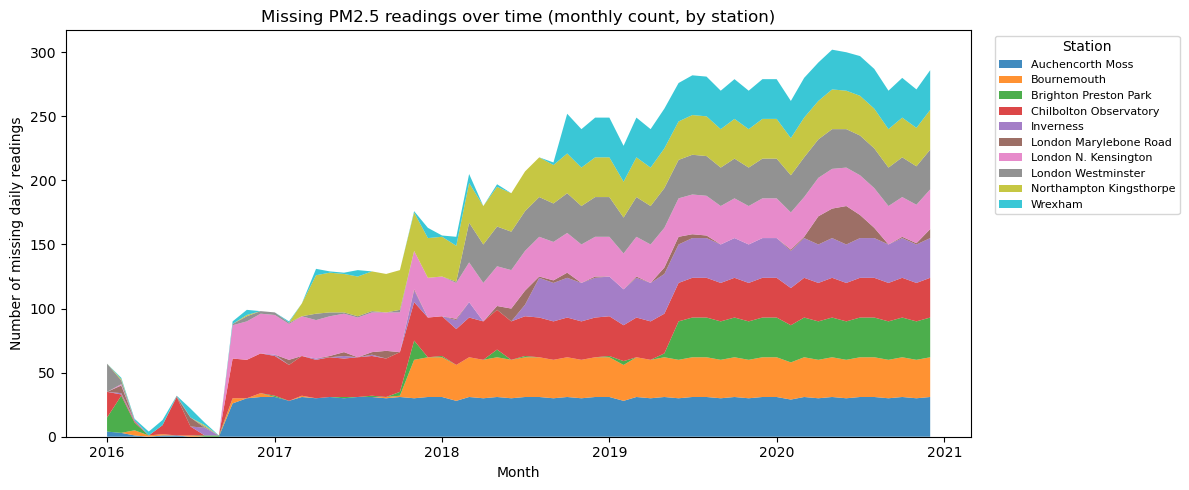

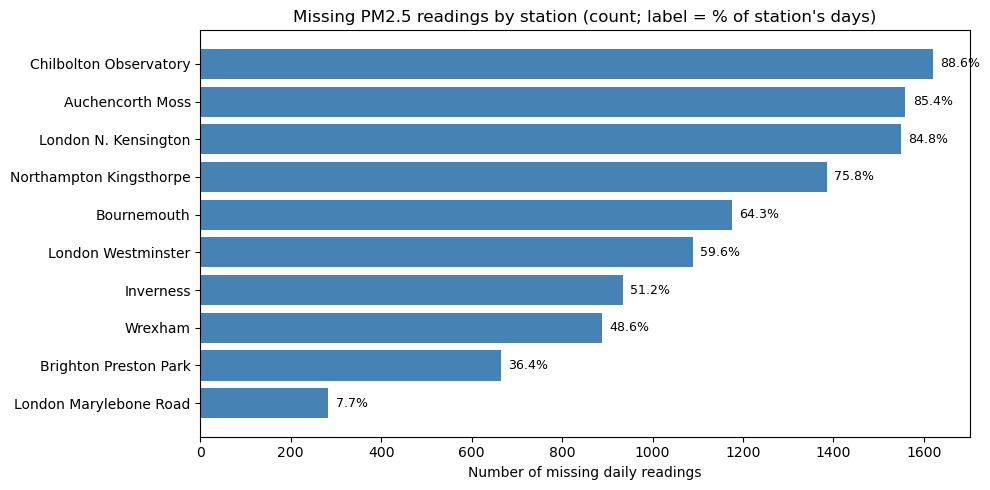


Worst stations by NA count:
                         na_count  pct_missing
station                                       
Chilbolton Observatory       1620         88.6
Auchencorth Moss             1559         85.4
London N. Kensington         1550         84.8
Northampton Kingsthorpe      1385         75.8
Bournemouth                  1175         64.3
London Westminster           1089         59.6
Inverness                     935         51.2
Wrexham                       889         48.6
Brighton Preston Park         665         36.4
London Marylebone Road        283          7.7

After dropping NA pm25_raw rows, shape: (8953, 4)


In [142]:
#how many NA's in pm25_raw? (these come from 'No data' / blank cells in the source CSVs)
na_pm25_count = df['pm25_raw'].isna().sum()
print(f'Number of NA values in pm25_raw: {na_pm25_count}')

# --- Plot 1: time span of NA's (monthly count, stacked by station) ---
na_rows = df[df['pm25_raw'].isna()].copy()
# station may be a pandas StringArray; cast to plain object so groupby/unstack
# produce a numeric-dtype matrix that plot(kind='area') accepts.
na_rows['station'] = na_rows['station'].astype(str)
na_rows['month'] = na_rows['date'].dt.to_period('M').dt.to_timestamp()
na_by_month_station = (na_rows.groupby(['month', 'station']).size()
                              .unstack(fill_value=0)
                              .sort_index()
                              .astype('int64'))

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(na_by_month_station.index,
             na_by_month_station.T.values,
             labels=na_by_month_station.columns,
             alpha=0.85)
ax.set_title('Missing PM2.5 readings over time (monthly count, by station)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of missing daily readings')
ax.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# --- Plot 2: worst stations (count + % of that station's days that are missing) ---
station_total = df.groupby('station').size()
station_na    = na_rows.groupby('station').size().reindex(station_total.index, fill_value=0)
station_pct   = (station_na / station_total * 100).round(1)

worst = (pd.DataFrame({'na_count': station_na, 'pct_missing': station_pct})
           .sort_values('na_count', ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(worst.index.astype(str), worst['na_count'].astype(int), color='steelblue')
for bar, pct in zip(bars, worst['pct_missing']):
    ax.text(bar.get_width() + max(worst['na_count']) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=9)
ax.set_title("Missing PM2.5 readings by station (count; label = % of station's days)")
ax.set_xlabel('Number of missing daily readings')
plt.tight_layout()
plt.show()

print('\nWorst stations by NA count:')
print(worst.sort_values('na_count', ascending=False))

# Drop NA rows now that we've inspected them
df = df.dropna(subset=['pm25_raw'])
print(f'\nAfter dropping NA pm25_raw rows, shape: {df.shape}')

#### How many stations?

In [143]:
#how many stations?
print(f'Unique stations: {df["station"].nunique()}')
print(f'Station names: {df["station"].unique()}')

Unique stations: 10
Station names: <StringArray>
[       'Auchencorth Moss',             'Bournemouth',
   'Brighton Preston Park',  'Chilbolton Observatory',
               'Inverness',  'London Marylebone Road',
    'London N. Kensington',      'London Westminster',
 'Northampton Kingsthorpe',                 'Wrexham']
Length: 10, dtype: str


#### Assign region to each station

In [144]:
# Group stations into UK regions so downstream code can enforce geographic
# diversity (national rule) and report rural-vs-urban patterns. Defined once
# here and used everywhere — do not redefine this dict in later cells.
STATION_REGION = {
    'Auchencorth Moss':        'Scotland',
    'Inverness':               'Scotland',
    'Wrexham':                 'Wales',
    'Northampton Kingsthorpe': 'Midlands',
    'Bournemouth':             'South',
    'Brighton Preston Park':   'South',
    'Chilbolton Observatory':  'South',
    'London Marylebone Road':  'London',
    'London N. Kensington':    'London',
    'London Westminster':      'London',
}
df['region'] = df['station'].map(STATION_REGION)

# Sanity check: every station should have a region
unmapped = df.loc[df['region'].isna(), 'station'].unique()
print(f'Stations missing a region mapping: {list(unmapped) if len(unmapped) else "none"}')
print('\nStations per region:')
print(df.groupby('region')['station'].nunique().sort_values(ascending=False))

Stations missing a region mapping: none

Stations per region:
region
London      3
South       3
Scotland    2
Midlands    1
Wales       1
Name: station, dtype: int64


#### Duplicate checks

In [145]:
#duplicates are when the same station has multiple readings for the same date (should be 1 reading per station per day)
duplicates = df.groupby(['date', 'station']).size()
duplicate_rows = duplicates[duplicates > 1]
print(f'\nNumber of duplicate date-station pairs: {len(duplicate_rows)}')
if len(duplicate_rows):
    print('Duplicate date-station pairs (date, station, count):')
    print(duplicate_rows.reset_index(name='count').to_string(index=False))  


Number of duplicate date-station pairs: 0


#### Outliers in PM2.5 values?

Global summary:
count    8953.00
mean        8.57
std         6.86
min         0.00
50%         6.60
90%        16.30
95%        21.60
99%        35.39
99.9%      59.80
max        92.22
Name: pm25_raw, dtype: float64

Readings above hard cap (250 ugm-3): 0

Per-station outlier summary (Q3 + 3*IQR rule):
                            n  median    p99    max  iqr_upper  n_outliers  \
station                                                                      
London Marylebone Road   3375    8.56  38.43  92.22      31.30          74   
Brighton Preston Park    1163    6.96  37.36  53.96      27.57          43   
Bournemouth               653    5.38  29.82  46.25      21.11          33   
London Westminster        739    7.00  42.61  79.63      28.52          24   
Wrexham                   939    5.10  29.30  49.09      24.36          24   
Northampton Kingsthorpe   442    5.02  37.01  48.71      25.23          20   
Inverness                 890    3.75  17.70  30.94      13.55         

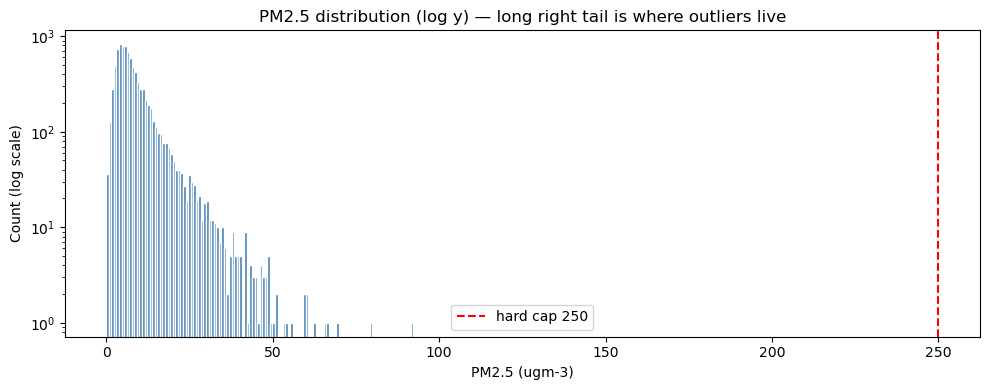

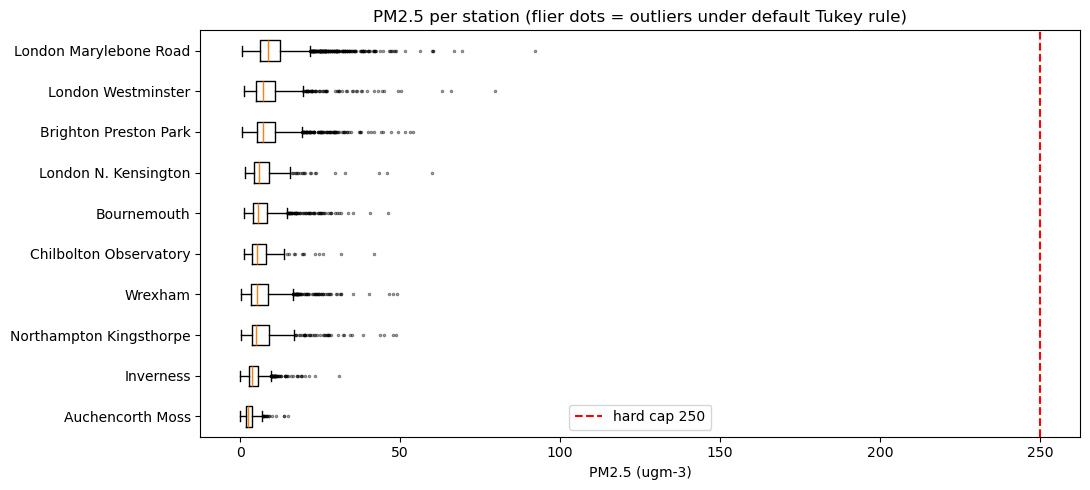

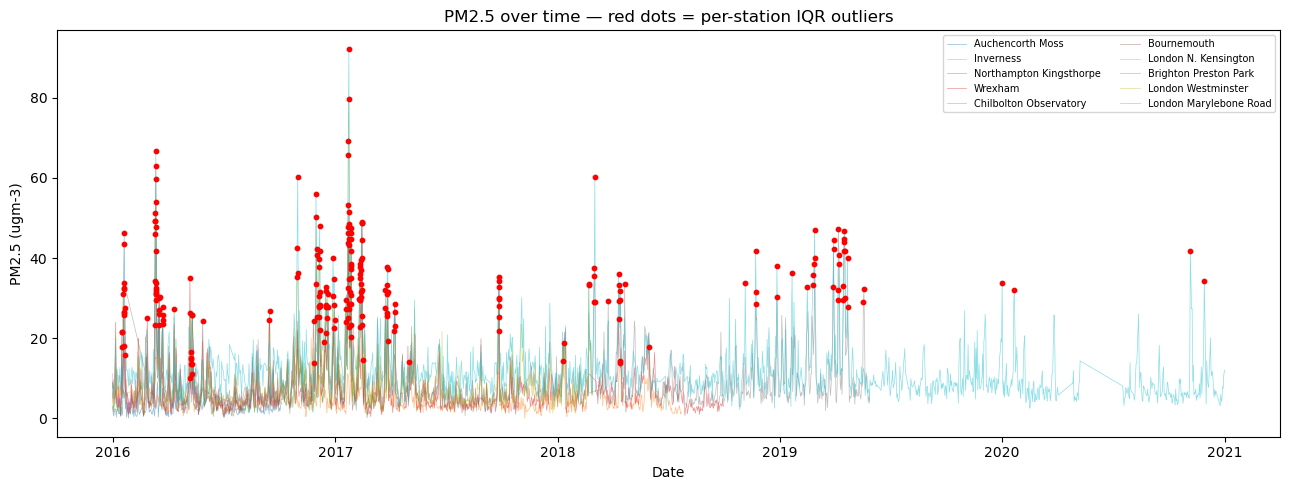

In [146]:
# --- Outlier inspection (no rows dropped here — just surface them) ---
# PM2.5 baselines differ a lot by site type (rural Auchencorth ~3 ugm-3 vs urban
# London Marylebone ~15 ugm-3), so a single global threshold is misleading.
# We check three lenses: hard cap, per-station IQR, and the top-N table.

PM25_HARD_CAP = 250  # Research actual limit?

print('Global summary:')
print(df['pm25_raw'].describe(percentiles=[.5, .9, .95, .99, .999]).round(2))

# 1) Hard cap
hard = df[df['pm25_raw'] > PM25_HARD_CAP]
print(f'\nReadings above hard cap ({PM25_HARD_CAP} ugm-3): {len(hard)}')
if len(hard):
    print(hard.sort_values('pm25_raw', ascending=False).head(10).to_string(index=False))

# 2) Per-station IQR rule (Tukey: > Q3 + 3*IQR is a "far" outlier)
# Use transform so the bound is broadcast back per row without losing the
# 'station' column (which groupby().apply() drops in newer pandas versions).
grouped = df.groupby('station')['pm25_raw']
q1 = grouped.transform(lambda s: s.quantile(0.25))
q3 = grouped.transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
flagged = df.copy()
flagged['iqr_upper']  = q3 + 3 * iqr
flagged['is_outlier'] = flagged['pm25_raw'] > flagged['iqr_upper']

per_station = (flagged.groupby('station')
                      .agg(n=('pm25_raw', 'size'),
                           median=('pm25_raw', 'median'),
                           p99=('pm25_raw', lambda s: s.quantile(0.99)),
                           max=('pm25_raw', 'max'),
                           iqr_upper=('iqr_upper', 'first'),
                           n_outliers=('is_outlier', 'sum'))
                      .assign(pct_outliers=lambda d: (d['n_outliers'] / d['n'] * 100).round(2))
                      .sort_values('n_outliers', ascending=False))
print('\nPer-station outlier summary (Q3 + 3*IQR rule):')
print(per_station.round(2))

# 3) Top 20 highest readings (with status + station context)
print('\nTop 20 highest PM2.5 readings:')
print(df.nlargest(20, 'pm25_raw')[['date', 'station', 'pm25_raw', 'status_raw']]
        .to_string(index=False))

# --- Plot 1: distribution (log y, so the long tail is visible) ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['pm25_raw'].dropna(), bins=120, color='steelblue', edgecolor='white')
ax.set_yscale('log')
ax.axvline(PM25_HARD_CAP, color='red', linestyle='--', label=f'hard cap {PM25_HARD_CAP}')
ax.set_title('PM2.5 distribution (log y) — long right tail is where outliers live')
ax.set_xlabel('PM2.5 (ugm-3)')
ax.set_ylabel('Count (log scale)')
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: per-station boxplot, sorted by median ---
order = (df.groupby('station')['pm25_raw'].median()
           .sort_values().index.astype(str).tolist())
data_by_station = [df.loc[df['station'].astype(str) == s, 'pm25_raw'].values for s in order]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(data_by_station, labels=order, vert=False, showfliers=True,
           flierprops=dict(marker='.', markersize=3, alpha=0.5))
ax.axvline(PM25_HARD_CAP, color='red', linestyle='--', label=f'hard cap {PM25_HARD_CAP}')
ax.set_title('PM2.5 per station (flier dots = outliers under default Tukey rule)')
ax.set_xlabel('PM2.5 (ugm-3)')
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 3: time series with per-station outliers highlighted ---
fig, ax = plt.subplots(figsize=(13, 5))
for s in order:
    sub = flagged[flagged['station'].astype(str) == s].sort_values('date')
    ax.plot(sub['date'], sub['pm25_raw'], linewidth=0.5, alpha=0.5, label=s)
    out = sub[sub['is_outlier']]
    ax.scatter(out['date'], out['pm25_raw'], s=10, color='red', zorder=3)
ax.set_title('PM2.5 over time — red dots = per-station IQR outliers')
ax.set_xlabel('Date'); ax.set_ylabel('PM2.5 (ugm-3)')
ax.legend(fontsize=7, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

AI Generated (check factualness):

Plot 1 — Distribution (log y)
A histogram of every PM2.5 reading, with a log-scale y-axis so even single rare readings stay visible instead of being swallowed by the bulk near zero. Anything to the right of the red 250 µg/m³ line is implausibly high for the UK and worth a closer look.

Plot 2 — Per-station boxplot
Each row shows one station's spread, sorted by median, so you can see at a glance that rural sites (Auchencorth, Inverness) sit far below the London sites. The dots past the whiskers are each station's own outliers, proving a global threshold is wrong, because 20 µg/m³ is extreme for Auchencorth but routine for Marylebone.

Plot 3 — Time series with outliers highlighted
Every station's daily readings plotted over time, with red dots marking that station's per-station IQR outliers. If red dots cluster on the same dates across multiple stations they're likely real pollution events (dust, fireworks, wildfire); if they're scattered on one station only, they're more likely sensor faults.
darker bands = stations clustered together (similar readings), fainter strands = a station diverging from the pack.

#### Train, validation, test split

move the longest continuous-day reading streaks to here.


Time series models require a continuous sequence of data for training and validation. By moving the longest continuous-day reading streaks to the train, validation, and test split section, we can ensure that our models are trained on reliable and uninterrupted data. Other options for handling gaps in the data include interpolation, forward/backward filling, or using models that can handle missing data. However, using continuous streaks of data is often the most straightforward and effective approach for time series modeling and given we have 989 days of continuous data, we can use that for training and validation without too much concern of underfitting.

In [147]:
# --- Per-day national-rule indicator ---
# How many distinct stations / regions report on each day, reindexed to the
# full daily range so missing days show up as False (rule not met).
df_plot = df.copy()
df_plot['date'] = df_plot['date'].dt.normalize()
full_range = pd.date_range(df_plot['date'].min(), df_plot['date'].max(), freq='D')

per_date = df_plot.groupby('date').agg(n_stations=('station', 'nunique'),
                                       n_regions=('region', 'nunique'))
rule_mask   = (per_date['n_stations'] >= 3) & (per_date['n_regions'] >= 2)
rule_series = rule_mask.reindex(full_range, fill_value=False)
print(f'Days where national rule is met: {int(rule_series.sum())} of {len(rule_series)} '
      f'({rule_series.mean()*100:.1f}%)')


Days where national rule is met: 989 of 1827 (54.1%)


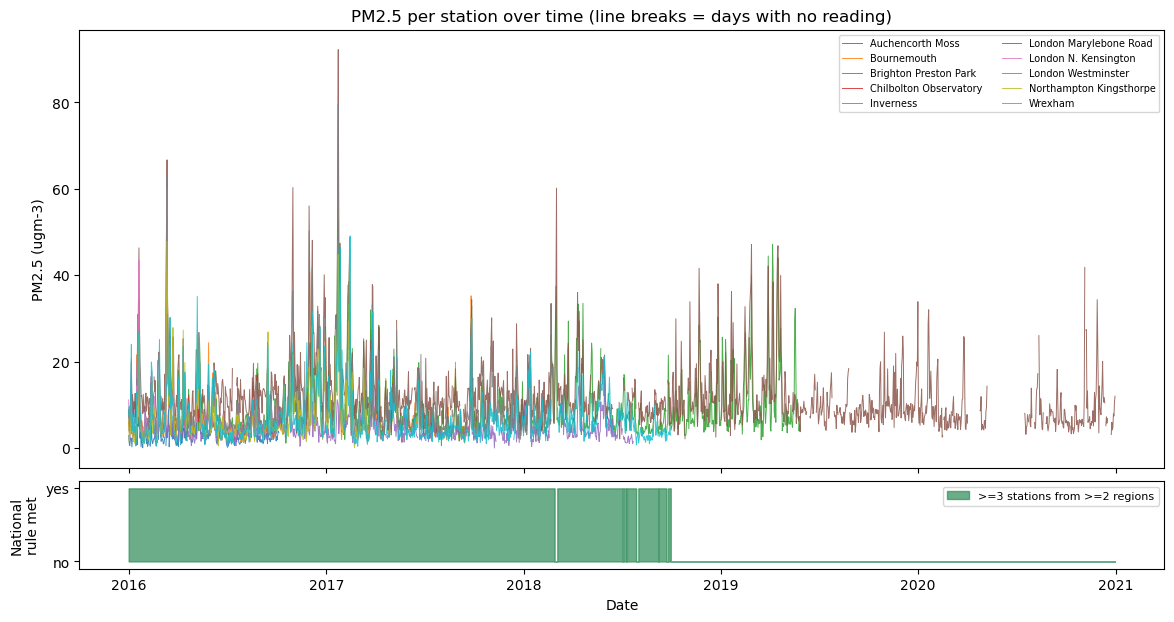

In [148]:
# --- Coverage plot: per-station lines + national-rule indicator ---
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(14, 7), sharex=True,
    gridspec_kw={'height_ratios': [5, 1], 'hspace': 0.05}
)

stations = sorted(df_plot['station'].astype(str).unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(stations)))
for s, c in zip(stations, colors):
    sub = (df_plot[df_plot['station'].astype(str) == s]
             .groupby('date')['pm25_raw'].mean()
             .reindex(full_range))
    ax_top.plot(sub.index, sub.values, linewidth=0.7, alpha=0.85, color=c, label=s)

ax_top.set_ylabel('PM2.5 (ugm-3)')
ax_top.set_title('PM2.5 per station over time (line breaks = days with no reading)')
ax_top.legend(fontsize=7, ncol=2, loc='upper right')

ax_bot.fill_between(full_range, 0, rule_series.astype(int).values,
                    step='mid', color='seagreen', alpha=0.7,
                    label='>=3 stations from >=2 regions')
ax_bot.set_ylim(-0.1, 1.1)
ax_bot.set_yticks([0, 1])
ax_bot.set_yticklabels(['no', 'yes'])
ax_bot.set_xlabel('Date'); ax_bot.set_ylabel('National\nrule met')
ax_bot.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


In [149]:
# --- Find every contiguous run where the national rule fails ---
fail  = ~rule_series
group = (fail != fail.shift()).cumsum()
runs  = (pd.DataFrame({'date': rule_series.index,
                       'fail': fail.values, 'group': group.values})
           .query('fail')
           .groupby('group')
           .agg(start=('date', 'min'), end=('date', 'max'),
                length_days=('date', 'size'))
           .reset_index(drop=True))
print(f'Total rule-failure runs: {len(runs)}')
print(runs.head(10).to_string(index=False))


Total rule-failure runs: 7
     start        end  length_days
2018-02-28 2018-03-04            5
2018-07-04 2018-07-04            1
2018-07-11 2018-07-11            1
2018-07-29 2018-08-01            4
2018-09-08 2018-09-08            1
2018-09-23 2018-09-25            3
2018-10-01 2020-12-31          823


In [150]:
# --- Gaps overlapping 2018 (sorted by length) ---
mask_2018 = (runs['start'].dt.year <= 2018) & (runs['end'].dt.year >= 2018)
gaps_2018 = runs[mask_2018].sort_values('length_days', ascending=False).copy()

print('Rule-failure gaps overlapping 2018:')
if gaps_2018.empty:
    print('  (none)')
else:
    print(gaps_2018.assign(start=gaps_2018['start'].dt.date,
                           end=gaps_2018['end'].dt.date)
                   .to_string(index=False))
    print(f'\nTotal rule-failing days inside 2018: '
          f'{int(fail.loc["2018"].sum())} of {len(fail.loc["2018"])}')


Rule-failure gaps overlapping 2018:
     start        end  length_days
2018-10-01 2020-12-31          823
2018-02-28 2018-03-04            5
2018-07-29 2018-08-01            4
2018-09-23 2018-09-25            3
2018-07-04 2018-07-04            1
2018-07-11 2018-07-11            1
2018-09-08 2018-09-08            1

Total rule-failing days inside 2018: 107 of 365


In [151]:
# --- Pick the biggest 2018-touching gap and its zoom window ---
gap = gaps_2018.iloc[0]   # already sorted by length descending

pad = pd.Timedelta(days=180)
win_start = max(gap['start'] - pad, full_range.min())
win_end   = min(gap['end']   + pad, full_range.max())
zoom_idx  = full_range[(full_range >= win_start) & (full_range <= win_end)]
print(f"Gap: {gap['start'].date()} -> {gap['end'].date()} "
      f"({gap['length_days']} days)")
print(f"Zoom window: {win_start.date()} -> {win_end.date()} ({len(zoom_idx)} days)")


Gap: 2018-10-01 -> 2020-12-31 (823 days)
Zoom window: 2018-04-04 -> 2020-12-31 (1003 days)


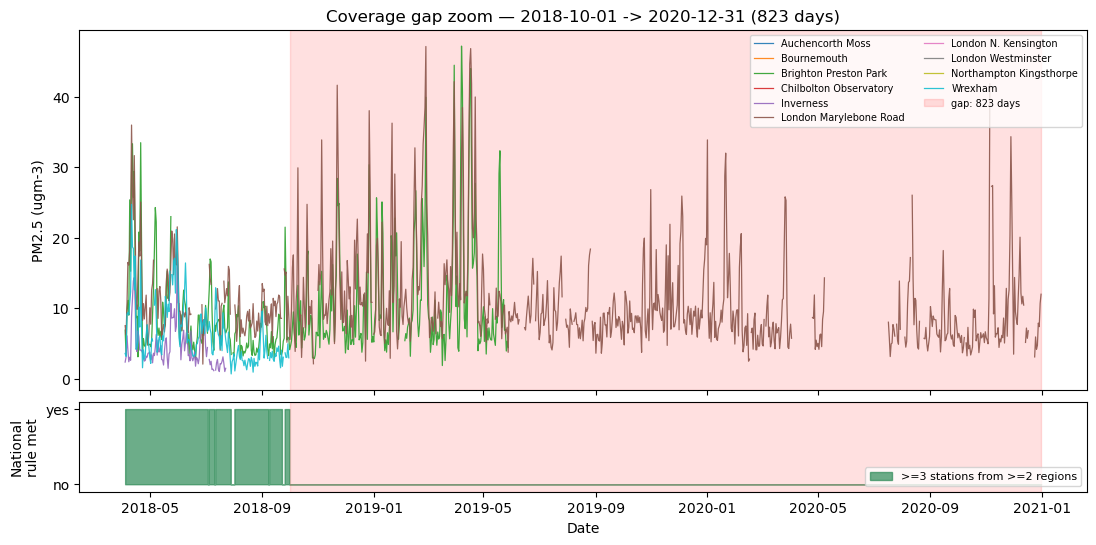

In [152]:
# --- Zoomed coverage plot around the chosen gap ---
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(13, 6), sharex=True,
    gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.05}
)

for s, c in zip(stations, colors):
    sub = (df_plot[df_plot['station'].astype(str) == s]
             .groupby('date')['pm25_raw'].mean()
             .reindex(zoom_idx))
    ax_top.plot(sub.index, sub.values, linewidth=0.9, alpha=0.9, color=c, label=s)

ax_top.axvspan(gap['start'], gap['end'], color='red', alpha=0.12,
               label=f"gap: {gap['length_days']} days")
ax_top.set_ylabel('PM2.5 (ugm-3)')
ax_top.set_title(f"Coverage gap zoom — {gap['start'].date()} -> {gap['end'].date()} "
                 f"({gap['length_days']} days)")
ax_top.legend(fontsize=7, ncol=2, loc='upper right')

ax_bot.fill_between(zoom_idx, 0, rule_series.loc[zoom_idx].astype(int).values,
                    step='mid', color='seagreen', alpha=0.7,
                    label='>=3 stations from >=2 regions')
ax_bot.axvspan(gap['start'], gap['end'], color='red', alpha=0.12)
ax_bot.set_ylim(-0.1, 1.1)
ax_bot.set_yticks([0, 1]); ax_bot.set_yticklabels(['no', 'yes'])
ax_bot.set_xlabel('Date'); ax_bot.set_ylabel('National\nrule met')
ax_bot.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()


#### Longest consecutive-day reading streaks

In [153]:
# --- Helper: longest consecutive-day run in a date series ---
def longest_run(dates: pd.Series) -> tuple[int, pd.Timestamp, pd.Timestamp]:
    """Return (length, start, end) of the longest run of consecutive daily dates."""
    if dates.empty:
        return 0, pd.NaT, pd.NaT
    d = pd.to_datetime(pd.Series(dates).dt.normalize().unique())
    d = pd.Series(d).sort_values().reset_index(drop=True)
    gap   = d.diff().dt.days.fillna(1)
    group = (gap != 1).cumsum()
    runs  = d.groupby(group).agg(['min', 'max', 'count'])
    best  = runs.loc[runs['count'].idxmax()]
    return int(best['count']), best['min'], best['max']


In [154]:
# --- Longest streak per station ---
rows = []
for station, sub in df.groupby('station'):
    n, start, end = longest_run(sub['date'])
    rows.append({'station': station, 'longest_run_days': n,
                 'start': start.date(), 'end': end.date()})
per_station_runs = (pd.DataFrame(rows)
                      .sort_values('longest_run_days', ascending=False)
                      .reset_index(drop=True))
print('Longest consecutive-day streak per station:')
print(per_station_runs.to_string(index=False))


Longest consecutive-day streak per station:
                station  longest_run_days      start        end
   London N. Kensington               233 2016-02-16 2016-10-05
 London Marylebone Road               202 2016-07-19 2017-02-05
Northampton Kingsthorpe               187 2016-02-21 2016-08-25
  Brighton Preston Park               184 2018-07-31 2019-01-30
            Bournemouth               183 2017-03-08 2017-09-06
              Inverness               153 2016-03-02 2016-08-01
     London Westminster               137 2017-10-14 2018-02-27
                Wrexham               127 2017-07-25 2017-11-28
       Auchencorth Moss               111 2016-06-17 2016-10-05
 Chilbolton Observatory                85 2016-07-08 2016-09-30


In [155]:
# --- Longest streak for the national rule ---
per_date_full = df.groupby('date').agg(n_stations=('station', 'nunique'),
                                       n_regions=('region', 'nunique'))
national_dates = per_date_full[(per_date_full['n_stations'] >= 3) &
                               (per_date_full['n_regions']  >= 2)].index.to_series()
n, start, end = longest_run(national_dates)
print(f'National rule (>=3 stations, >=2 regions):')
print(f'  longest gap-free run: {n} days  ({start.date()} -> {end.date()})')
print(f'  total qualifying days: {len(national_dates)}')


National rule (>=3 stations, >=2 regions):
  longest gap-free run: 789 days  (2016-01-01 -> 2018-02-27)
  total qualifying days: 989


## What do about the gaps?

It appears that post 09 2018, large gaps in the data appear and continue to voliate our national rule from this point forward. We can either drop these stations entirely, or we can use interpolation to fill in the gaps. 

We will drop all data after 09 2018, as this is the point where the data becomes unreliable and violates our national rule and there is no reasonable way to interpolate the data without introducing bias or inaccuracies. By dropping this data, we can ensure that our analysis and modeling are based on reliable and consistent data.

#### Filling gaps pre 09 2018:

The gaps in the data pre 09 2018 are relatively small and can be filled using interpolation.

We will use multiple methods for this:

Short gaps - Linear interpolation: For gaps of 1-2 days, we can use linear interpolation to fill in the missing values. This method assumes that the change between the two known values is linear and can be used to estimate the missing value. This will create 'straight lines' between the known values, which is a reasonable assumption for short gaps.

Medium gaps - Cross-station regression: For gaps of 3+ days, we can use cross-station regression to fill in the missing values. This method uses the readings from co-reporting stations to estimate the missing value based on the relationship between the stations. This will create a more accurate estimate of the missing value, as it takes into account the readings from other stations.

In order to use cross-station regression, we will need to first split our data into training and testing sets. We will use the training set to build the regression model and the testing set to evaluate its performance. This will prevent data leakage.

## Chronological split:

Chronological split is a method of splitting the data into training, validation, and test sets based on time. This is important for time series modeling, as it ensures that the model is trained on past data and tested on future data.

In [156]:
# --- Universe and split window definitions ---
# Restrict the modelling universe to the pre-cliff period and split it
# chronologically (never shuffled).
UNIVERSE_START = '2016-01-01'
UNIVERSE_END   = '2018-09-30'

SPLITS = [
    ('train', '2016-01-01', '2017-12-31'),   # 24 mo, two full seasonal cycles
    ('val',   '2018-01-01', '2018-04-30'),   # 4 mo, hyperparameter tuning
    ('test',  '2018-05-01', '2018-09-30'),   # 5 mo, held-out forecast window
]


In [157]:
# --- Filter to the universe and assign a split label to every row ---
in_universe = (df['date'] >= pd.Timestamp(UNIVERSE_START)) & \
              (df['date'] <= pd.Timestamp(UNIVERSE_END))
df = df[in_universe].copy()

def assign_split(d):
    for name, lo, hi in SPLITS:
        if pd.Timestamp(lo) <= d <= pd.Timestamp(hi):
            return name
    return 'unassigned'

df['split'] = df['date'].apply(assign_split).astype('category')
print(f'Universe: {UNIVERSE_START} -> {UNIVERSE_END}')
print(f'Total rows after restriction: {len(df)}')


Universe: 2016-01-01 -> 2018-09-30
Total rows after restriction: 6288


In [158]:
# --- Per-split coverage summary ---
summary = (df.groupby('split', observed=True)
             .agg(rows=('pm25_raw', 'size'),
                  first_date=('date', 'min'),
                  last_date=('date', 'max'),
                  n_stations=('station', 'nunique'),
                  n_regions=('region', 'nunique'),
                  pct_verified=('status_raw',
                                lambda s: round((s == 'V ugm-3 (GRAV EMFAB)').mean() * 100, 1)))
             .reindex([name for name, _, _ in SPLITS]))
print(summary.to_string())


       rows first_date  last_date  n_stations  n_regions  pct_verified
split                                                                 
train  5283 2016-01-01 2017-12-31          10          5         100.0
val     502 2018-01-01 2018-04-30           5          4         100.0
test    503 2018-05-01 2018-09-30           4          4         100.0


In [159]:
# --- Convenience slices + sanity check ---
train_df = df[df['split'] == 'train'].copy()
val_df   = df[df['split'] == 'val'].copy()
test_df  = df[df['split'] == 'test'].copy()
print(f"Shapes -> train: {train_df.shape}, val: {val_df.shape}, test: {test_df.shape}")

overlap = (df.groupby(['date', 'station'])['split'].nunique() > 1).sum()
print(f'Rows where the same (date, station) lands in 2+ splits: {overlap}  (should be 0)')


Shapes -> train: (5283, 6), val: (502, 6), test: (503, 6)
Rows where the same (date, station) lands in 2+ splits: 0  (should be 0)


In [160]:
# --- Pivot to wide (date x station) for per-station interpolation ---
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

wide = (df.pivot_table(index='date', columns='station',
                       values='pm25_raw', aggfunc='mean')
          .reindex(pd.date_range(UNIVERSE_START, UNIVERSE_END, freq='D')))
observed = wide.notna()  # snapshot of what was observed before any filling
print(f'Wide matrix shape: {wide.shape}  (rows = days, cols = stations)')
print(f'Cells observed: {int(observed.sum().sum())};  cells NaN: {int((~observed).sum().sum())}')


Wide matrix shape: (1004, 10)  (rows = days, cols = stations)
Cells observed: 6288;  cells NaN: 3752


In [161]:
# --- Per-cell NaN-run length ---
# For each NaN cell, store the length of the run it belongs to; observed cells = 0.
def gap_run_length(col):
    is_na = col.isna()
    grp = (is_na != is_na.shift()).cumsum()
    return is_na.groupby(grp).transform('size') * is_na.astype(int)
gap_len = wide.apply(gap_run_length)

run_dist = (gap_len.stack(future_stack=True)
                   .pipe(lambda s: s[s > 0])
                   .value_counts()
                   .sort_index())
print('Per-station NaN-run length distribution (length -> cells):')
print(run_dist.to_string())


Per-station NaN-run length distribution (length -> cells):
1        69
2        24
3        27
4        20
5        20
6        24
7        28
9         9
11       11
18       18
19       19
20       20
21       21
42       42
43       43
69       69
215     215
335     335
558     558
725    1450
730     730


In [162]:
# --- Tier 1: linear interpolation for runs of length 1-2 ---
linear_filled = wide.interpolate(method='linear', limit=2, limit_area='inside')
short_mask = (gap_len >= 1) & (gap_len <= 2)
wide_after_short = wide.where(~short_mask, linear_filled)
n_short = int((wide.isna() & wide_after_short.notna()).sum().sum())
print(f'Cells linear-interpolated (1-2 day runs): {n_short}')


Cells linear-interpolated (1-2 day runs): 93


In [163]:
# --- Tier 2: cross-station regression for any gap >=3 days ---
# Fit on TRAIN rows only so val/test never inform the regression coefficients.
train_lo, train_hi = SPLITS[0][1], SPLITS[0][2]
train_rows = (wide_after_short.index >= pd.Timestamp(train_lo)) & \
             (wide_after_short.index <= pd.Timestamp(train_hi))

imputer = IterativeImputer(estimator=BayesianRidge(),
                           random_state=0, max_iter=25)
imputer.fit(wide_after_short.loc[train_rows].values)
predicted = pd.DataFrame(imputer.transform(wide_after_short.values),
                         index=wide_after_short.index,
                         columns=wide_after_short.columns)

medium_mask = (gap_len >= 3)
wide_filled = wide_after_short.where(~medium_mask, predicted)
n_medium = int((wide_after_short.isna() & wide_filled.notna()).sum().sum())
n_left   = int(wide_filled.isna().sum().sum())
print(f'Cells regression-imputed (>=3 day runs): {n_medium}')
print(f'Cells left as NaN (imputer NaN):        {n_left}')


Cells regression-imputed (>=3 day runs): 3659
Cells left as NaN (imputer NaN):        0


In [164]:
# --- Rebuild long-format df with pm25_imputed flag ---
long_pm25 = (wide_filled.stack(future_stack=True)
                        .rename('pm25_raw')
                        .reset_index())
long_pm25.columns = ['date', 'station', 'pm25_raw']
long_obs = observed.stack(future_stack=True).rename('was_observed').reset_index()
long_obs.columns = ['date', 'station', 'was_observed']

df = long_pm25.merge(long_obs, on=['date', 'station'])
df = df.dropna(subset=['pm25_raw']).reset_index(drop=True)
df['pm25_imputed'] = ~df['was_observed']
df = df.drop(columns=['was_observed'])
df['region'] = df['station'].map(STATION_REGION)
df['split']  = df['date'].apply(assign_split).astype('category')

print(f'Long-format df after interpolation: {df.shape}')
print(f'  observed rows: {(~df["pm25_imputed"]).sum()}')
print(f'  imputed rows:  {df["pm25_imputed"].sum()}')
print('\nImputed rows per split:')
print(df.groupby('split', observed=True)['pm25_imputed']
        .agg(['size', 'sum'])
        .rename(columns={'size': 'rows', 'sum': 'imputed'})
        .assign(pct_imputed=lambda d: (d['imputed'] / d['rows'] * 100).round(2))
        .to_string())


Long-format df after interpolation: (10040, 6)
  observed rows: 6288
  imputed rows:  3752

Imputed rows per split:
       rows  imputed  pct_imputed
split                            
test   1530     1027        67.12
train  7310     2027        27.73
val    1200      698        58.17


In [165]:
# --- Aggregate per date: mean PM2.5 + coverage diagnostics ---
national = (df.groupby('date', as_index=False)
              .agg(pm25=('pm25_raw', 'mean'),
                   n_stations=('station', 'nunique'),
                   n_regions=('region', 'nunique'),
                   split=('split', 'first')))
print(f'National shape (before reindex): {national.shape}')


National shape (before reindex): (1004, 5)


In [166]:
# --- Strict daily index across the universe so any gaps stay visible ---
full_idx = pd.date_range(UNIVERSE_START, UNIVERSE_END, freq='D', name='date')
national = national.set_index('date').reindex(full_idx).reset_index()
national['split'] = (national['split']
                     .fillna(national['date'].apply(assign_split))
                     .astype('category'))
print(f'National shape (after reindex): {national.shape}')
print(f'Rows added by reindex (no station reported): {national["pm25"].isna().sum()}')


National shape (after reindex): (1004, 5)
Rows added by reindex (no station reported): 0


In [167]:
# --- Mask rule-failing days to NaN + per-split summary ---
rule_fails = ((national['n_stations'].fillna(0) < 3) |
              (national['n_regions'].fillna(0)  < 2))
national.loc[rule_fails, 'pm25'] = np.nan

print(f'Days masked as NaN (no rule-quality reading): {int(rule_fails.sum())}')
print('\nPer-split summary of national series:')
print(national.groupby('split', observed=True)
              .agg(rows=('pm25', 'size'),
                   missing=('pm25', lambda s: int(s.isna().sum())),
                   mean_pm25=('pm25', 'mean'),
                   median_pm25=('pm25', 'median'),
                   min_stations=('n_stations', 'min'),
                   max_stations=('n_stations', 'max'))
              .round(2)
              .to_string())
print('\nHead:')
print(national.head().to_string(index=False))


Days masked as NaN (no rule-quality reading): 0

Per-split summary of national series:
       rows  missing  mean_pm25  median_pm25  min_stations  max_stations
split                                                                   
test    153        0       6.35         5.78            10            10
train   731        0       7.75         5.92            10            10
val     120        0       8.39         6.59            10            10

Head:
      date     pm25  n_stations  n_regions split
2016-01-01 7.243895          10          5 train
2016-01-02 4.859402          10          5 train
2016-01-03 4.836465          10          5 train
2016-01-04 5.354090          10          5 train
2016-01-05 7.781122          10          5 train


In [168]:
def find_rule_gaps(df, split_name):
    sub = df[df['split'] == split_name]
    per_day = sub.groupby('date').agg(n_stations=('station', 'nunique'),
                                      n_regions=('region', 'nunique'))
    rule_ok = (per_day['n_stations'] >= 3) & (per_day['n_regions'] >= 2)
    all_dates = pd.date_range(per_day.index.min(), per_day.index.max())
    # missing = physically absent OR present but fails the rule
    physically_missing = all_dates.difference(per_day.index)
    rule_failing       = per_day.index[~rule_ok]
    return physically_missing.union(rule_failing).sort_values()

for split_name in ['train', 'val', 'test']:
    gaps = find_rule_gaps(df, split_name)
    print(f"{split_name}: {len(gaps)} day(s) failing national rule")
    if len(gaps):
        print(f"  {list(gaps.strftime('%Y-%m-%d'))}")

train: 0 day(s) failing national rule
val: 0 day(s) failing national rule
test: 0 day(s) failing national rule


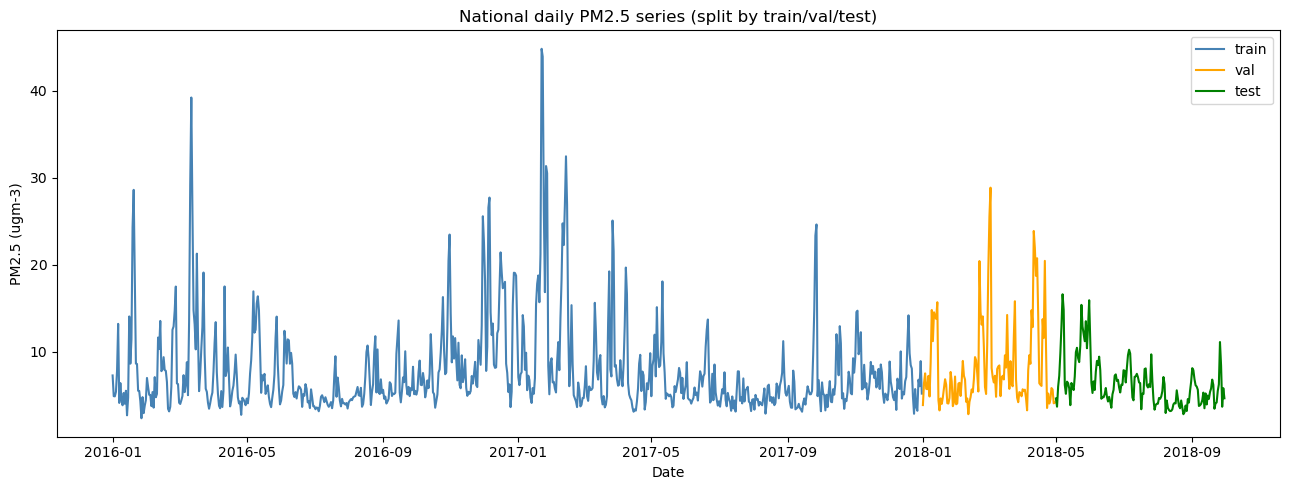

In [169]:
#plot time series of each split

fig, ax = plt.subplots(figsize=(13, 5))
for split_name, color in zip(['train', 'val', 'test'], ['steelblue', 'orange', 'green']):
    sub = national[national['split'] == split_name]
    ax.plot(sub['date'], sub['pm25'], label=split_name, color=color)
ax.set_title('National daily PM2.5 series (split by train/val/test)')
ax.set_xlabel('Date'); ax.set_ylabel('PM2.5 (ugm-3)')
ax.legend()
plt.tight_layout()
plt.show()
